In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
import random
import scipy
from scipy.stats import mannwhitneyu

import seaborn as sns

plt.style.use('styleNB.mplstyle')

wt = 'dHL60KW'
ko = 'dHL60TMEM154KO'

# Function for subsampling 
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out


# Figure 3 - Supplemental Related - EL4 cell line

## Load in data

In [98]:
# LOAD in the .csv data file of cell tracks
df = pd.read_csv('../../data/processed_3D_tracking/20250429_compiled_EL-4_TMEM154_KO_lines.csv')

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20:# 14:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_filtered_tracks.celltype.unique()

array(['EL4 KO12', 'EL4 KO12 + Galvanin-eGFP-HA', 'EL4 WT',
       'EL4 WT + Galvanin-eGFP-HA'], dtype=object)

In [99]:
# for supplemental, keep simple and just consider WT and KO
df_filtered_tracks = df_filtered_tracks[df_filtered_tracks.celltype != 'EL4 WT + Galvanin-eGFP-HA']
df_filtered_tracks = df_filtered_tracks[df_filtered_tracks.celltype != 'EL4 KO12 + Galvanin-eGFP-HA']

color_dict = {'EL4 WT': '#B8BABC',
 'EL4 KO12': (1.0, 0.4980392156862745, 0.054901960784313725)}

In [100]:
df_filtered_tracks.head()

,celltype,E_V_cm,date,trial,user,cell,frame,x,y
0,EL4 KO12,0,20250315,0,HK,5,0.0,474.885894,626.245151
1,EL4 KO12,0,20250315,0,HK,5,1.0,476.475097,625.803959
2,EL4 KO12,0,20250315,0,HK,5,2.0,478.922463,625.859465
3,EL4 KO12,0,20250315,0,HK,5,3.0,478.028059,625.290090
4,EL4 KO12,0,20250315,0,HK,5,4.0,477.388413,624.353928


# Cell trajectories

('EL4 KO12', 0)
201
('EL4 KO12', 1)
201
('EL4 KO12', 3)
201
('EL4 WT', 0)
201
('EL4 WT', 1)
201
('EL4 WT', 3)
201


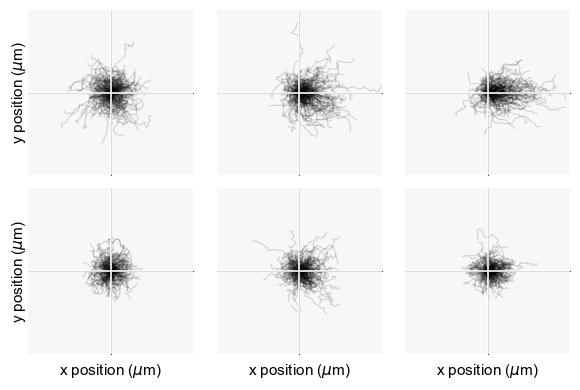

In [107]:
f, ax = plt.subplots(2, 3, figsize=(6, 4))
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'EL4 WT': 0, 'EL4 KO12': 1}


for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if count_cell > 200:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1
        
    print(count_cell)

    ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-130, 130)
    ax_.set_ylim(-130, 130)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Hide x labels if not in bottom row
        if r < n_rows - 1:
            ax_.set_xlabel('')
            ax_.tick_params(labelbottom=False)

        # Hide y labels if not in leftmost column
        if c > 0:
            ax_.set_ylabel('')
            ax_.tick_params(labelleft=False)

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Keep axis labels only on outer left and bottom
        if r < n_rows - 1:
            ax_.set_xlabel('')
        if c > 0:
            ax_.set_ylabel('')

        # Remove all tick labels
        ax_.set_xticklabels([])
        ax_.set_yticklabels([])

        # Optional: reduce tick mark length
        ax_.tick_params(length=0)
            
plt.tight_layout()
f.savefig('../../figures/Figure4_supplemental_EL4_tracks.pdf', bbox_inches='tight')

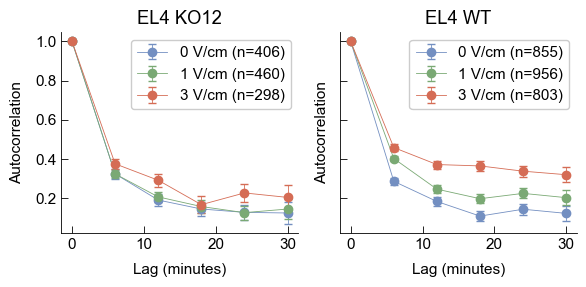

In [102]:
# Step 1: Define interval (number of frames between points)
interval = 3 # use same as HL-60

# Step 2: subsample
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)


###############################
# Autocorrelation calculation
###############################
    
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr
        

autocorr_list = []

for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * interval,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        ax.errorbar(
            2*d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=3, marker='o'
        )
    ax.set_title(celltype)
    ax.set_xlabel('Lag (minutes)')
    ax.set_ylabel('Autocorrelation')
    ax.legend()
plt.tight_layout()

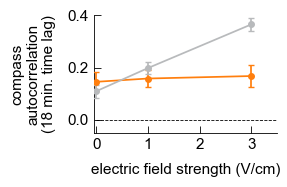

In [103]:
# Choose lag of interest (in minutes)
lag_of_interest = 9  # e.g., for 6 min
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Group by condition
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(3, 2))

for celltype, d in df_lag_stats.groupby('celltype'):
    ax.errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1.25, marker='o', markersize=4,
        color=color_dict.get(celltype, None),  # fallback if not in dict
        zorder=10, capsize=2
    )

ax.hlines(0, 0, df_lag_stats['E_V_cm'].max() + 0.5, color='k', linestyle='--', zorder=0)

ax.set_xlim(-0.05, 3.5)
ax.set_ylim(-0.05, 0.4)

ax.set_xlabel('electric field strength (V/cm)')
ax.set_ylabel(f'compass\nautocorrelation\n({lag_of_interest*2} min. time lag)')

# Move legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
# plt.savefig('../../figures/Figure3_autocorrelation_updated.pdf')


# Average speed calculations


0 V/cm
  EL4 KO12: 44 cells, mean 0.0290
  EL4 KO12: 50 cells, mean 0.0305
  EL4 KO12: 40 cells, mean 0.0279
  EL4 KO12: 88 cells, mean 0.0291
  EL4 KO12: 91 cells, mean 0.0296
  EL4 KO12: 93 cells, mean 0.0306
  EL4 WT: 91 cells, mean 0.0323
  EL4 WT: 84 cells, mean 0.0342
  EL4 WT: 82 cells, mean 0.0351
  EL4 WT: 81 cells, mean 0.0366
  EL4 WT: 102 cells, mean 0.0373
  EL4 WT: 89 cells, mean 0.0352
  EL4 WT: 47 cells, mean 0.0417
  EL4 WT: 50 cells, mean 0.0410
  EL4 WT: 45 cells, mean 0.0390
  EL4 WT: 65 cells, mean 0.0443
  EL4 WT: 58 cells, mean 0.0446
  EL4 WT: 61 cells, mean 0.0400

1 V/cm
  EL4 KO12: 46 cells, mean 0.0286
  EL4 KO12: 39 cells, mean 0.0289
  EL4 KO12: 47 cells, mean 0.0295
  EL4 KO12: 102 cells, mean 0.0315
  EL4 KO12: 121 cells, mean 0.0322
  EL4 KO12: 105 cells, mean 0.0357
  EL4 WT: 93 cells, mean 0.0341
  EL4 WT: 97 cells, mean 0.0340
  EL4 WT: 94 cells, mean 0.0334
  EL4 WT: 83 cells, mean 0.0357
  EL4 WT: 115 cells, mean 0.0412
  EL4 WT: 93 cells, mean 0.

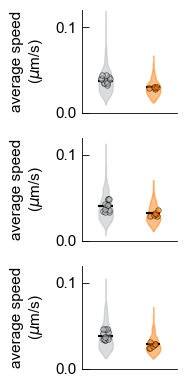

In [104]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))[::-1]))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths]  # exclude 5 V/cm

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]
    print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                # Use 2D or 3D displacement depending on z availability
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60)  # μm/sec
                

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
            # print(speed_prep)

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=10
                )
                speed_all.extend(speed_prep)
                print(f"  {celltype}: {len(speed_prep)} cells, mean {np.mean(speed_prep):.4f}")

        # Plot violin if there’s data
        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=1.5, zorder=10)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_ylim(0, 0.12)
    a.set_yticks([0.0, 0.1])
    a.set_ylabel('average speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()
# plt.savefig('../../figures/Figure3_avg_speeds_updated.pdf')

# combined plots


0 V/cm

1 V/cm

3 V/cm


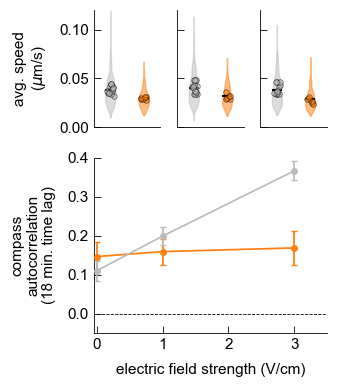

In [106]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# =============================
# Layout: 3 speed violins + 1 cosine directionality plot
# =============================
fig = plt.figure(figsize=(3.5, 4))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.5])
ax_speed = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_compass = fig.add_subplot(gs[1, :])  # Full-width bottom plot

# -----------------------------
# Speed violin plots
# -----------------------------
celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))[::-1]))
field_strengths = [e for e in sorted(df_intervals['E_V_cm'].unique())]

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]
    print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []
    
        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_prep = []
    
            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue
                d = d.sort_values('interval')
    
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values
    
                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60)  # μm/sec
    
                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
    
            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax_speed[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=10
                )
                speed_all.extend(speed_prep)
    
        # plot 1 violin per celltype
        if len(speed_all) > 0:
            vp = ax_speed[ax_idx].violinplot(
                [speed_all], positions=[ind],  # just 1 dataset per call
                points=60, widths=0.3, showmeans=False,
                showextrema=False, showmedians=False, bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

        ax_speed[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                                color='k', lw=1.5, zorder=10)

    # Style all top-row axes
    for i, a in enumerate(ax_speed):
        a.set_xlim(-0.5, len(celltypes) - 0.5)
        a.set_ylim(0, 0.12)
        a.set_yticks([0.0, 0.05, 0.1])
        a.set_ylabel('avg. speed\n' + r'($\mu$m/s)' if i == 0 else '')  # Label only first plot
        a.xaxis.set_visible(False)
    
        if i > 0:
            a.tick_params(labelleft=False)  # Hide y-axis tick labels on all but first

# -----------------------------
# compass autocorrelation
# -----------------------------
# Choose lag of interest (in minutes)
lag_of_interest = 9  # e.g., for 6 min
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Group by condition
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

for celltype, d in df_lag_stats.groupby('celltype'):
    ax_compass.errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1.25, marker='o', markersize=4,
        color=color_dict.get(celltype, None),  # fallback if not in dict
        zorder=10, capsize=2
    )

ax_compass.hlines(0, 0, df_lag_stats['E_V_cm'].max() + 0.5, color='k', linestyle='--', zorder=0)

ax_compass.set_xlim(-0.05, 3.5)
ax_compass.set_ylim(-0.05, 0.4)

ax_compass.set_xlabel('electric field strength (V/cm)')
ax_compass.set_ylabel(f'compass\nautocorrelation\n({lag_of_interest*2} min. time lag)')

# # Move legend outside
# box = ax_compass.get_position()
# ax_compass.set_position([box.x0, box.y0, box.width * 0.8, box.height])

plt.tight_layout()
plt.show()

fig.savefig('../../figures/Figure4_supplemental_EL4_20250523.pdf', bbox_inches='tight')

### perform statisics

In [68]:
interval = 3
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)

# Prepare output for review
E_field_values = sorted(df_intervals['E_V_cm'].unique())

for E in E_field_values:
    df_E = df_intervals[df_intervals.E_V_cm == E]

    # Initialize containers
    grouped_speeds = {
        'EL4 WT': [],
        'EL4 KO12': []
    }

    for celltype in grouped_speeds.keys():
        df_ct = df_E[df_E.celltype == celltype]
        speed_per_trial = []

        for _, trial_df in df_ct.groupby(['date', 'trial', 'user'], sort=False):
            speed_per_cell = []

            for _, d in trial_df.groupby('cell'):
                d = d.sort_values('interval')
                if len(d) <= 1:
                    continue

                # Choose 2D or 3D based on z column presence
                use_z = 'z' in d.columns and not d['z'].isnull().any()
                pos = d[['x', 'y', 'z']].values if use_z else d[['x', 'y']].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60.0)  # μm/sec

                if len(speeds) > 0:
                    speed_per_cell.append(np.mean(speeds))

            if len(speed_per_cell) > 0:
                trial_mean = np.mean(speed_per_cell)
                speed_per_trial.append(trial_mean)

        grouped_speeds[celltype] = speed_per_trial

    # Perform statistical comparisons
    print(f"\n{E} V/cm average speed comparisons:")

    try:
        res = mannwhitneyu(grouped_speeds['EL4 WT'], grouped_speeds['EL4 KO12'], alternative='two-sided')
        print(f"  KO vs WT: U={res.statistic:.1f}, p={res.pvalue:.3g}, n={len(grouped_speeds['EL4 WT'])} vs {len(grouped_speeds['EL4 KO12'])}")
    except ValueError:
        print("  KO vs WT: insufficient data")



KO vs WT: MannwhitneyuResult(statistic=0.0, pvalue=0.00010773540185304891)
Rescue vs WT: MannwhitneyuResult(statistic=nan, pvalue=nan)


/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_13595/2810861285.py:42: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print('Rescue vs WT:', mannwhitneyu(speed_all_res, speed_all_kw, alternative='two-sided'))


KO vs WT: MannwhitneyuResult(statistic=4.0, pvalue=0.001292824822236587)
